# What Makes a Game Immortal? — EDA & Feasibility Checks

**COM-480 Data Visualization Project**

This notebook validates whether the RAWG dataset can support the "Immortal Games" data story.
We check data quality and feasibility for each planned visualization beat:

1. **Decay curve** — Does `added_by_status` give us a usable "still alive" ratio? How does it distribute by release year?
2. **Completion paradox** — Can we actually see the "never finished, still playing" cluster?
3. **Tag fingerprints** — Are tags clean enough to compare immortal vs mortal games?
4. **Community signals** — Are reddit/twitch/youtube counts populated enough to be useful?
5. **Mortality index** — Can we build a composite score from these variables?

## 0. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import ast
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print('Ready. Load the dataset below.')

Ready. Load the dataset below.


In [2]:
# === LOAD DATA ===
# Option A: If you downloaded the parquet files from HuggingFace
# df = pd.read_parquet('path/to/rawg-games-dataset/')  # folder with .parquet shards

# Option B: Direct from HuggingFace (requires datasets library + internet)
# from datasets import load_dataset
# ds = load_dataset('atalaydenknalbant/rawg-games-dataset', split='train')
# df = ds.to_pandas()

# Option C: If you exported to CSV
df = pd.read_csv('rawg-games-dataset.csv')

# --- Uncomment ONE of the above and run ---
# df = pd.read_parquet('rawg-games-dataset/')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset shape: (889793, 54)
Columns: ['id', 'slug', 'name', 'released', 'background_image', 'rating', 'rating_top', 'ratings_count', 'reviews_text_count', 'added', 'playtime', 'suggestions_count', 'updated', 'reviews_count', 'saturated_color', 'dominant_color', 'platforms', 'stores', 'developers', 'genres', 'tags', 'publishers', 'esrb_rating', 'added_by_status', 'metacritic_url', 'ratings', 'clip', 'name_original', 'reddit_url', 'reactions', 'parents_count', 'background_image_additional', 'website', 'reddit_count', 'youtube_count', 'short_screenshots', 'creators_count', 'twitch_count', 'metacritic_platforms', 'screenshots_count', 'parent_platforms', 'description', 'description_raw', 'metacritic', 'achievements_count', 'alternative_names', 'parent_achievements_count', 'game_series_count', 'additions_count', 'movies_count', 'reddit_name', 'reddit_description', 'reddit_logo', 'tba']


,id,slug,name,released,background_image,rating,rating_top,ratings_count,reviews_text_count,added,...,achievements_count,alternative_names,parent_achievements_count,game_series_count,additions_count,movies_count,reddit_name,reddit_description,reddit_logo,tba
0,19103,half-life-2-lost-coast,Half-Life 2: Lost Coast,2005-10-27,https://media.rawg.io/media/games/b7b/b7b83817...,3.45,4.0,1164.0,3.0,11676.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12020,left-4-dead-2,Left 4 Dead 2,2009-11-17,https://media.rawg.io/media/games/d58/d588947d...,4.09,4.0,3355.0,25.0,17398.0,...,166.0,L4D2,102.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2,13536,portal,Portal,2007-10-09,https://media.rawg.io/media/games/7fa/7fa0b586...,4.49,5.0,4896.0,44.0,17582.0,...,15.0,ポータル|포털,15.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN


In [22]:
df['tags'].head(5)

0    Singleplayer|Multiplayer|Atmospheric|Great Sou...
1    Singleplayer|Steam Achievements|Multiplayer|Fu...
2    Singleplayer|Steam Achievements|Atmospheric|Gr...
3    Singleplayer|Steam Achievements|Multiplayer|Fu...
4    Singleplayer|Full controller support|Atmospher...
Name: tags, dtype: object

## 1. Parse `added_by_status` — The Critical Field

This field contains JSON-like strings with keys: `beaten`, `dropped`, `owned`, `playing`, `toplay`, `yet`.
If this field is garbage, the whole project falls apart. Let's check.

In [3]:
# Inspect raw values
print('=== Raw added_by_status samples ===')
print(df['added_by_status'].dropna().head(10).to_list())
print(f'\nNull count: {df["added_by_status"].isna().sum()} / {len(df)} ({df["added_by_status"].isna().mean()*100:.1f}%)')

=== Raw added_by_status samples ===
['{"beaten":1066,"dropped":178,"owned":9637,"playing":6,"toplay":80,"yet":709}', '{"beaten":2613,"dropped":1236,"owned":12885,"playing":154,"toplay":116,"yet":394}', '{"beaten":5216,"dropped":422,"owned":11105,"playing":86,"toplay":285,"yet":468}', '{"beaten":858,"dropped":1681,"owned":9396,"playing":544,"toplay":114,"yet":194}', '{"beaten":3507,"dropped":663,"owned":10297,"playing":153,"toplay":374,"yet":794}', '{"beaten":1117,"dropped":2101,"owned":14089,"playing":631,"toplay":79,"yet":267}', '{"beaten":2386,"dropped":1323,"owned":11043,"playing":220,"toplay":249,"yet":641}', '{"beaten":2781,"dropped":433,"owned":7807,"playing":159,"toplay":404,"yet":675}', '{"beaten":1660,"dropped":914,"owned":6973,"playing":533,"toplay":655,"yet":858}', '{"beaten":3436,"dropped":746,"owned":8666,"playing":949,"toplay":1658,"yet":995}']

Null count: 777331 / 889793 (87.4%)


In [4]:
def parse_added_by_status(val):
    """Parse the added_by_status field into a dict."""
    if pd.isna(val):
        return {}
    if isinstance(val, dict):
        return val
    try:
        # Try JSON parse
        return json.loads(val.replace("'", '"'))
    except:
        try:
            return ast.literal_eval(val)
        except:
            return {}

# Parse into separate columns
status_parsed = df['added_by_status'].apply(parse_added_by_status)
status_df = pd.DataFrame(status_parsed.tolist())

for col in ['beaten', 'dropped', 'owned', 'playing', 'toplay', 'yet']:
    if col in status_df.columns:
        df[f'status_{col}'] = pd.to_numeric(status_df[col], errors='coerce').fillna(0)
    else:
        df[f'status_{col}'] = 0

print('Parsed status columns:')
print(df[['status_beaten', 'status_dropped', 'status_owned', 'status_playing', 'status_toplay', 'status_yet']].describe())

Parsed status columns:
       status_beaten  status_dropped   status_owned  status_playing  \
count  889793.000000   889793.000000  889793.000000   889793.000000   
mean        1.390373        0.718449      11.212680        0.146467   
std        36.900750       14.303951     158.536009        4.333346   
min         0.000000        0.000000       0.000000        0.000000   
25%         0.000000        0.000000       0.000000        0.000000   
50%         0.000000        0.000000       0.000000        0.000000   
75%         0.000000        0.000000       0.000000        0.000000   
max      6283.000000     2101.000000   14089.000000      949.000000   

       status_toplay     status_yet  
count  889793.000000  889793.000000  
mean        0.541469       0.718544  
std        10.662164      11.395091  
min         0.000000       0.000000  
25%         0.000000       0.000000  
50%         0.000000       0.000000  
75%         0.000000       0.000000  
max      2440.000000    1181.0000

In [5]:
# Compute the "still alive" ratio
# alive_ratio = playing / (playing + beaten + dropped)

df['engagement_total'] = df['status_playing'] + df['status_beaten'] + df['status_dropped']
df['alive_ratio'] = df['status_playing'] / df['engagement_total']
df['alive_ratio'] = df['alive_ratio'].replace([np.inf, -np.inf], np.nan)

# Lower threshold to capture more games
MIN_ENGAGEMENT = 30
df_valid = df[df['engagement_total'] >= MIN_ENGAGEMENT].copy()

print(f'Games with engagement >= {MIN_ENGAGEMENT}: {len(df_valid)} / {len(df)} ({len(df_valid)/len(df)*100:.1f}%)')
print(f'alive_ratio stats for valid games:')
print(df_valid['alive_ratio'].describe())

# Preview immortality thresholds
for thresh in [0.20, 0.15, 0.10, 0.08, 0.05]:
    n = (df_valid['alive_ratio'] > thresh).sum()
    print(f'  alive_ratio > {thresh}: {n} games total')


Games with engagement >= 30: 7052 / 889793 (0.8%)
alive_ratio stats for valid games:
count    7052.000000
mean        0.065258
std         0.077663
min         0.000000
25%         0.018848
50%         0.040541
75%         0.088097
max         0.933333
Name: alive_ratio, dtype: float64
  alive_ratio > 0.2: 348 games total
  alive_ratio > 0.15: 759 games total
  alive_ratio > 0.1: 1459 games total
  alive_ratio > 0.08: 1951 games total
  alive_ratio > 0.05: 3041 games total


## 2. Parse Release Dates & Build the Decay Curve

Release year distribution (valid games):
count    7033.000000
mean     2011.399545
std         8.409148
min      1971.000000
25%      2007.000000
50%      2013.000000
75%      2018.000000
max      2025.000000
Name: release_year, dtype: float64

Null release dates: 19

Year range: 1971.0 - 2025.0


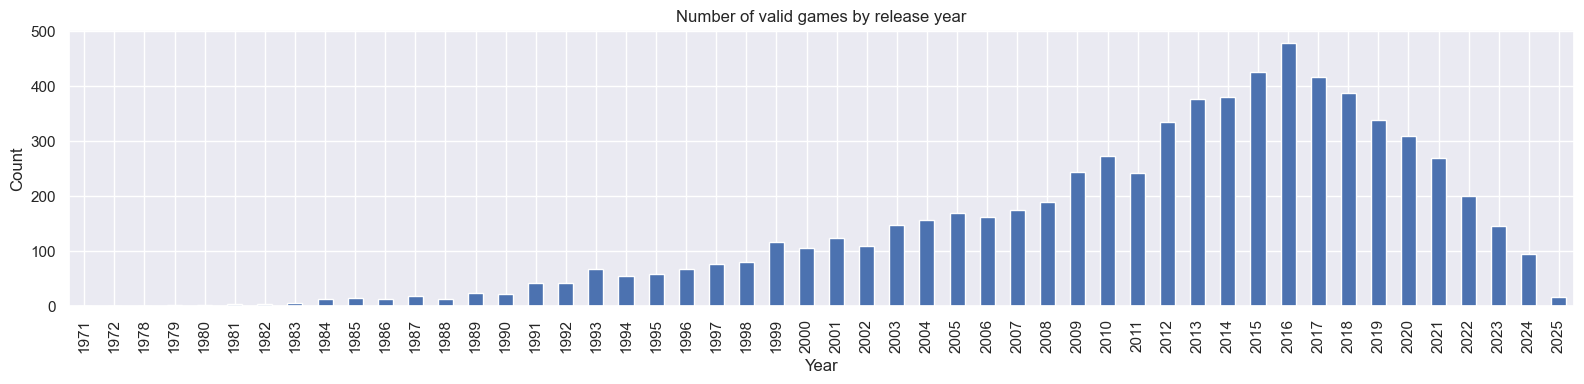

In [6]:
# Parse release year
df_valid['released_dt'] = pd.to_datetime(df_valid['released'], errors='coerce')
df_valid['release_year'] = df_valid['released_dt'].dt.year

print('Release year distribution (valid games):')
print(df_valid['release_year'].describe())
print(f'\nNull release dates: {df_valid["release_year"].isna().sum()}')
print(f'\nYear range: {df_valid["release_year"].min()} - {df_valid["release_year"].max()}')

# Distribution
df_valid['release_year'].dropna().astype(int).value_counts().sort_index().plot(kind='bar', figsize=(16, 4))
plt.title('Number of valid games by release year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

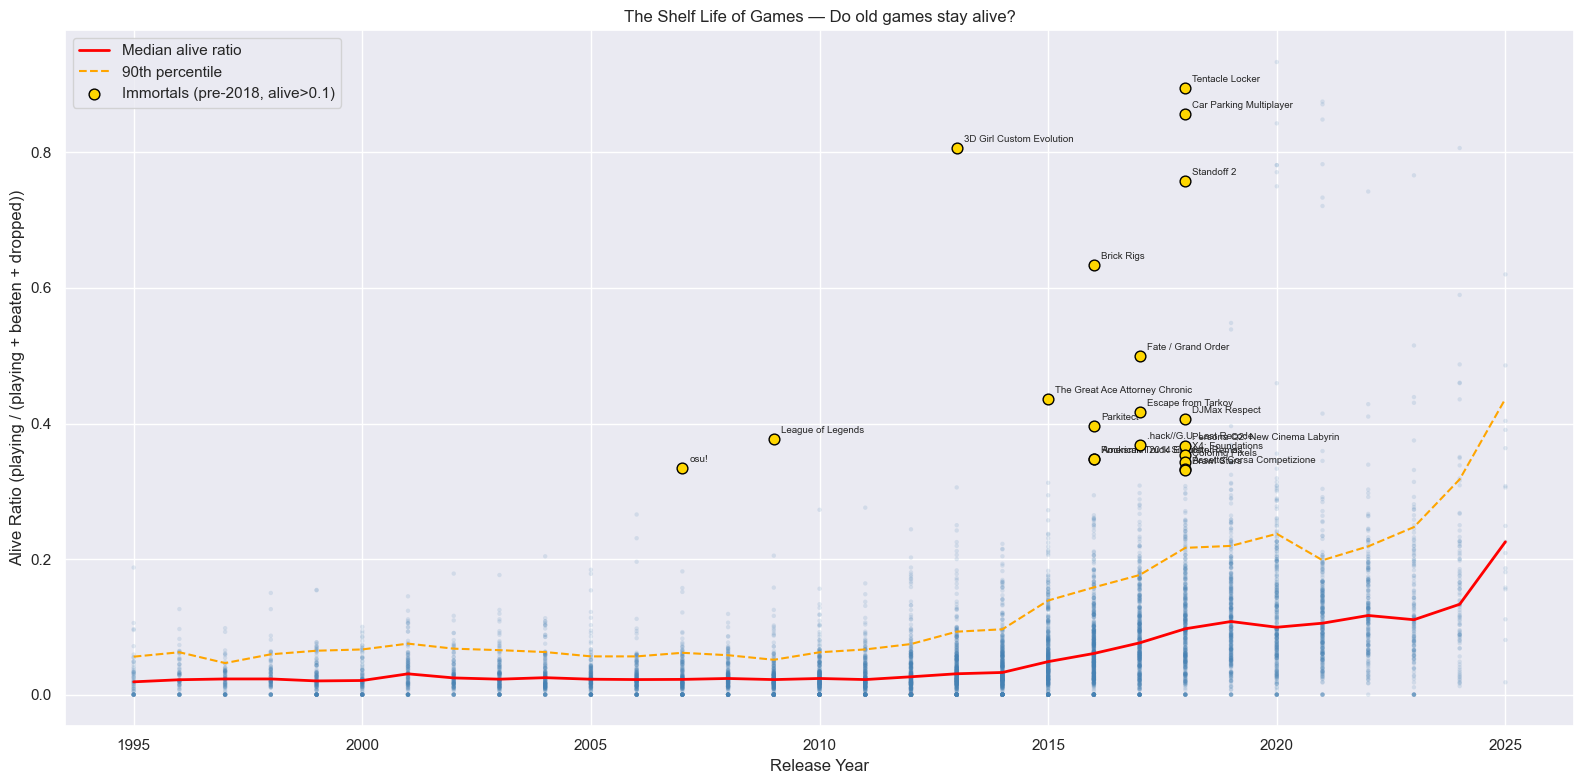


Immortal candidates (pre-2018, alive>0.1): 683

=== Top 25 Immortal Games ===
                                                         name  release_year  alive_ratio  status_playing  status_beaten  status_dropped  engagement_total                    genres  rating
1550                                          Tentacle Locker        2018.0     0.895210           299.0           16.0            19.0             334.0              Arcade|Indie    4.33
10774                                 Car Parking Multiplayer        2018.0     0.857143            36.0            4.0             2.0              42.0  Simulation|Sports|Racing    4.33
10081                                3D Girl Custom Evolution        2013.0     0.806452            25.0            2.0             4.0              31.0                Simulation    3.85
7244                                               Standoff 2        2018.0     0.758242            69.0            2.0            20.0              91.0          Action

In [7]:
# === THE KEY CHART: Alive ratio vs Release Year ===
if 'release_year' not in df_valid.columns:
    df_valid['released_dt'] = pd.to_datetime(df_valid['released'], errors='coerce')
    df_valid['release_year'] = df_valid['released_dt'].dt.year

plot_df = df_valid.dropna(subset=['release_year', 'alive_ratio']).copy()
plot_df = plot_df[(plot_df['release_year'] >= 1995) & (plot_df['release_year'] <= 2025)]

fig, ax = plt.subplots(figsize=(16, 8))
ax.scatter(plot_df['release_year'], plot_df['alive_ratio'], 
           alpha=0.15, s=10, c='steelblue', edgecolors='none')

# Median line per year
yearly_median = plot_df.groupby('release_year')['alive_ratio'].median()
ax.plot(yearly_median.index, yearly_median.values, color='red', linewidth=2, label='Median alive ratio')

# 90th percentile line
yearly_p90 = plot_df.groupby('release_year')['alive_ratio'].quantile(0.9)
ax.plot(yearly_p90.index, yearly_p90.values, color='orange', linewidth=1.5, linestyle='--', label='90th percentile')

# SOFTENED THRESHOLD
IMMORTAL_YEAR_CUTOFF = 2018
IMMORTAL_ALIVE_THRESH = 0.10

old_immortals = plot_df[(plot_df['release_year'] <= IMMORTAL_YEAR_CUTOFF) & (plot_df['alive_ratio'] > IMMORTAL_ALIVE_THRESH)]
old_immortals_top = old_immortals.nlargest(20, 'alive_ratio')

ax.scatter(old_immortals_top['release_year'], old_immortals_top['alive_ratio'],
           s=60, c='gold', edgecolors='black', zorder=5, label=f'Immortals (pre-{IMMORTAL_YEAR_CUTOFF}, alive>{IMMORTAL_ALIVE_THRESH})')

for _, row in old_immortals_top.iterrows():
    ax.annotate(row['name'][:30], (row['release_year'], row['alive_ratio']),
                fontsize=7, ha='left', va='bottom', 
                xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Release Year')
ax.set_ylabel('Alive Ratio (playing / (playing + beaten + dropped))')
ax.set_title('The Shelf Life of Games — Do old games stay alive?')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nImmortal candidates (pre-{IMMORTAL_YEAR_CUTOFF}, alive>{IMMORTAL_ALIVE_THRESH}): {len(old_immortals)}')
print(f'\n=== Top 25 Immortal Games ===')
cols = ['name', 'release_year', 'alive_ratio', 'status_playing', 'status_beaten', 'status_dropped', 'engagement_total', 'genres', 'rating']
cols = [c for c in cols if c in old_immortals.columns]
print(old_immortals.nlargest(25, 'alive_ratio')[cols].to_string())


## 3. The Completion Paradox

Do immortal games have LOW beaten rates but HIGH playing rates? 
Plot beaten_rate vs playing_rate and see if clusters emerge.

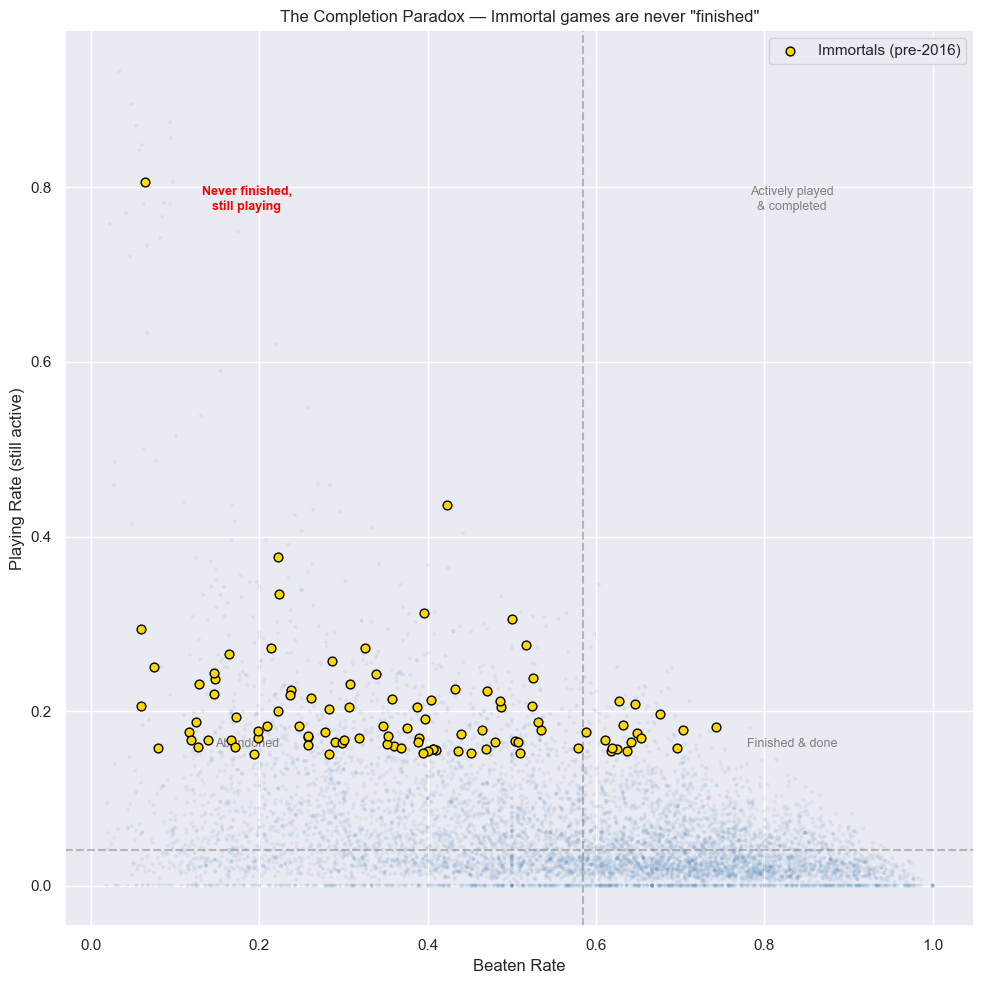

In [8]:
# Compute rates
df_valid['beaten_rate'] = df_valid['status_beaten'] / df_valid['engagement_total']
df_valid['playing_rate'] = df_valid['status_playing'] / df_valid['engagement_total']
df_valid['dropped_rate'] = df_valid['status_dropped'] / df_valid['engagement_total']

fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(df_valid['beaten_rate'], df_valid['playing_rate'],
                     alpha=0.1, s=8, c='steelblue', edgecolors='none')

# Quadrant lines
ax.axhline(y=df_valid['playing_rate'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=df_valid['beaten_rate'].median(), color='gray', linestyle='--', alpha=0.5)

# Label quadrants
ax.text(0.8, 0.8, 'Actively played\n& completed', transform=ax.transAxes, ha='center', fontsize=9, color='gray')
ax.text(0.2, 0.8, 'Never finished,\nstill playing', transform=ax.transAxes, ha='center', fontsize=9, color='red', fontweight='bold')
ax.text(0.8, 0.2, 'Finished & done', transform=ax.transAxes, ha='center', fontsize=9, color='gray')
ax.text(0.2, 0.2, 'Abandoned', transform=ax.transAxes, ha='center', fontsize=9, color='gray')

# Highlight immortals
immortals_mask = (df_valid['release_year'] <= 2015) & (df_valid['alive_ratio'] > 0.15)
ax.scatter(df_valid.loc[immortals_mask, 'beaten_rate'], 
           df_valid.loc[immortals_mask, 'playing_rate'],
           s=40, c='gold', edgecolors='black', zorder=5, label='Immortals (pre-2016)')

ax.set_xlabel('Beaten Rate')
ax.set_ylabel('Playing Rate (still active)')
ax.set_title('The Completion Paradox — Immortal games are never "finished"')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Tag Analysis — What DNA do immortals share?

In [9]:
# Inspect tag format
print('=== Raw tag samples ===')
for t in df_valid['tags'].dropna().head(5):
    print(repr(t[:200]))
    print()

=== Raw tag samples ===
'Singleplayer|Multiplayer|Atmospheric|Great Soundtrack|First-Person|Sci-fi|FPS|Classic|Free to Play|Short|Futuristic|Aliens|Dystopian|Commentary available|Illuminati|Silent Protagonist|Benchmark'

'Singleplayer|Steam Achievements|Multiplayer|Full controller support|Steam Cloud|steam-trading-cards|Co-op|cooperative|First-Person|Horror|FPS|Online Co-Op|Gore|Survival|Local Co-Op|Tactical|stats|Stea'

'Singleplayer|Steam Achievements|Atmospheric|Great Soundtrack|Story Rich|First-Person|Sci-fi|Partial Controller Support|FPS|Funny|Classic|Female Protagonist|Comedy|Includes level editor|Captions availa'

'Singleplayer|Steam Achievements|Multiplayer|Full controller support|Steam Cloud|steam-trading-cards|Great Soundtrack|Co-op|cooperative|Online Co-Op|Funny|Split Screen|Local Co-Op|Local Multiplayer|sta'

'Singleplayer|Full controller support|Atmospheric|steam-trading-cards|Great Soundtrack|Story Rich|Third Person|Female Protagonist|Dark|Point & Click|Mystery|Short|Choi

In [10]:
def parse_tags(val):
    """Parse tags string into a list. Handles pipe-separated and comma-separated."""
    if pd.isna(val) or val == '':
        return []
    # Try pipe separator first (seen in the HF preview)
    if '|' in str(val):
        return [t.strip() for t in str(val).split('|') if t.strip()]
    # Try comma separator
    return [t.strip() for t in str(val).split(',') if t.strip()]

df_valid['tag_list'] = df_valid['tags'].apply(parse_tags)
df_valid['n_tags'] = df_valid['tag_list'].apply(len)

# All unique tags and their frequency
from collections import Counter
all_tags = Counter()
for tags in df_valid['tag_list']:
    all_tags.update(tags)

print(f'Unique tags: {len(all_tags)}')
print(f'\nTop 30 tags:')
for tag, count in all_tags.most_common(30):
    print(f'  {tag}: {count} ({count/len(df_valid)*100:.1f}%)')

Unique tags: 1839

Top 30 tags:
  Singleplayer: 4866 (69.0%)
  Steam Achievements: 2628 (37.3%)
  Multiplayer: 2357 (33.4%)
  Steam Cloud: 1828 (25.9%)
  Full controller support: 1797 (25.5%)
  Atmospheric: 1411 (20.0%)
  steam-trading-cards: 1328 (18.8%)
  Great Soundtrack: 1207 (17.1%)
  RPG: 1196 (17.0%)
  Co-op: 1155 (16.4%)
  cooperative: 1102 (15.6%)
  Story Rich: 1082 (15.3%)
  2D: 1039 (14.7%)
  Open World: 890 (12.6%)
  Horror: 877 (12.4%)
  First-Person: 849 (12.0%)
  Partial Controller Support: 806 (11.4%)
  Third Person: 747 (10.6%)
  Sci-fi: 710 (10.1%)
  Fantasy: 699 (9.9%)
  Funny: 661 (9.4%)
  Online Co-Op: 645 (9.1%)
  FPS: 624 (8.8%)
  exclusive: 620 (8.8%)
  Steam Leaderboards: 590 (8.4%)
  Exploration: 578 (8.2%)
  Female Protagonist: 574 (8.1%)
  Gore: 572 (8.1%)
  Difficult: 547 (7.8%)
  Classic: 539 (7.6%)


Using 23 key tags
Immortal games (pre-2018, alive>0.1): 690
Mortal games (pre-2018, alive<=0.03): 2739


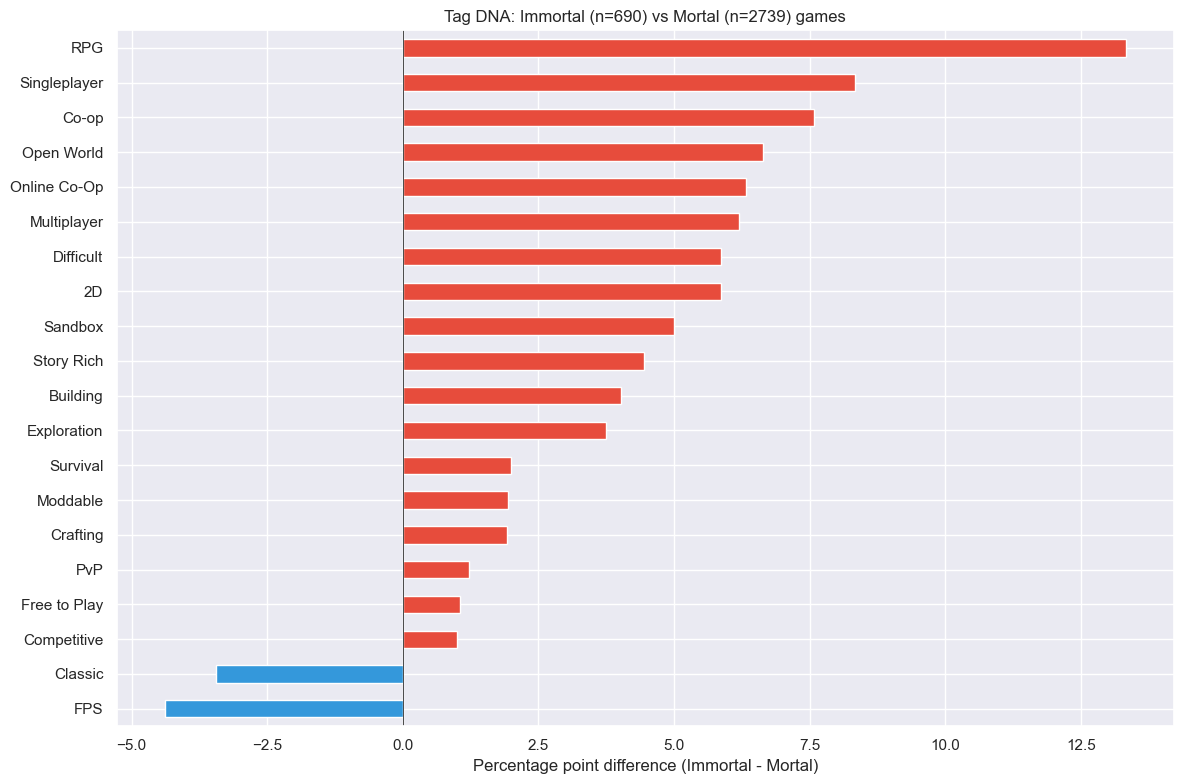

              Immortal %   Mortal %  Difference
FPS             5.652174  10.040161   -4.387987
Classic         6.231884   9.675064   -3.443180
Team-Based      1.594203   1.679445   -0.085242
Horror         10.289855  10.295728   -0.005873
Atmospheric    17.101449  16.173786    0.927663
Competitive     2.753623   1.752464    1.001159
Free to Play    6.521739   5.476451    1.045288
PvP             3.768116   2.555677    1.212439
Crafting        3.043478   1.131800    1.911678
Moddable        3.913043   1.971522    1.941521
Survival        6.956522   4.965316    1.991206
Exploration     7.826087   4.089084    3.737003
Building        5.362319   1.350858    4.011461
Story Rich     15.072464  10.624315    4.448148
Sandbox         9.565217   4.563709    5.001508
2D             17.246377  11.391019    5.855358
Difficult      11.884058   6.024096    5.859962
Multiplayer    39.855072  33.661920    6.193152
Online Co-Op   12.318841   5.987587    6.331254
Open World     16.376812   9.748083    6

In [11]:
# Compare tag profiles: immortal vs mortal games
IMMORTAL_YEAR_CUTOFF = 2018
IMMORTAL_ALIVE_THRESH = 0.10
MORTAL_ALIVE_THRESH = 0.03

KEY_TAGS = [
    'Singleplayer', 'Multiplayer', 'Co-op', 'Online Co-Op',
    'Open World', 'Sandbox', 'Story Rich', 'Atmospheric',
    'Competitive', 'PvP', 'Free to Play', 'Moddable',
    'Survival', 'RPG', 'FPS', 'Indie',
    'Building', 'Crafting', 'Team-Based', 'Exploration',
    'Horror', 'Difficult', '2D', 'Classic',
]
KEY_TAGS = [t for t in KEY_TAGS if t in all_tags]
print(f'Using {len(KEY_TAGS)} key tags')

for tag in KEY_TAGS:
    df_valid[f'tag_{tag}'] = df_valid['tag_list'].apply(lambda x, t=tag: t in x)

immortal_mask = (df_valid['release_year'] <= IMMORTAL_YEAR_CUTOFF) & (df_valid['alive_ratio'] > IMMORTAL_ALIVE_THRESH)
mortal_mask = (df_valid['release_year'] <= IMMORTAL_YEAR_CUTOFF) & (df_valid['alive_ratio'] <= MORTAL_ALIVE_THRESH)

immortal_games = df_valid[immortal_mask]
mortal_games = df_valid[mortal_mask]

print(f'Immortal games (pre-{IMMORTAL_YEAR_CUTOFF}, alive>{IMMORTAL_ALIVE_THRESH}): {len(immortal_games)}')
print(f'Mortal games (pre-{IMMORTAL_YEAR_CUTOFF}, alive<={MORTAL_ALIVE_THRESH}): {len(mortal_games)}')

comparison = pd.DataFrame({
    'Immortal %': [immortal_games[f'tag_{t}'].mean() * 100 for t in KEY_TAGS],
    'Mortal %': [mortal_games[f'tag_{t}'].mean() * 100 for t in KEY_TAGS],
}, index=KEY_TAGS)
comparison['Difference'] = comparison['Immortal %'] - comparison['Mortal %']
comparison = comparison.sort_values('Difference', ascending=True)

# Only show tags with meaningful difference
comparison_filtered = comparison[comparison['Difference'].abs() > 1]

fig, ax = plt.subplots(figsize=(12, max(6, len(comparison_filtered) * 0.4)))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in comparison_filtered['Difference']]
comparison_filtered['Difference'].plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Percentage point difference (Immortal - Mortal)')
ax.set_title(f'Tag DNA: Immortal (n={len(immortal_games)}) vs Mortal (n={len(mortal_games)}) games')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(comparison.to_string())


## 5. Community Signals — Reddit, Twitch, YouTube

Are these fields populated enough? Do immortals have disproportionate community presence?

In [12]:
# Check coverage of community signals
community_cols = ['reddit_count', 'youtube_count', 'twitch_count']

for col in community_cols:
    non_null = df_valid[col].notna().sum()
    non_zero = (df_valid[col].fillna(0) > 0).sum()
    print(f'{col}:')
    print(f'  Non-null: {non_null} ({non_null/len(df_valid)*100:.1f}%)')
    print(f'  Non-zero: {non_zero} ({non_zero/len(df_valid)*100:.1f}%)')
    print(f'  Stats: min={df_valid[col].min():.0f}, median={df_valid[col].median():.0f}, max={df_valid[col].max():.0f}')
    if col == 'youtube_count':
        at_cap = (df_valid[col] == 1_000_000).sum()
        print(f'  ⚠️  AT 1M CAP: {at_cap} games ({at_cap/non_zero*100:.0f}% of non-zero) — limited analytical value')
    print()

print('VERDICT:')
print('  - Twitch: best signal (70% coverage, real dynamic range)')
print('  - Reddit: cleanest but sparse (20%)')
print('  - YouTube: capped at 1M, most games near ceiling — use cautiously')
print('  → Lead community beat with Twitch, supplement with Reddit')


reddit_count:
  Non-null: 1124 (15.9%)
  Non-zero: 1124 (15.9%)
  Stats: min=1, median=960, max=12230

youtube_count:
  Non-null: 4923 (69.8%)
  Non-zero: 4923 (69.8%)
  Stats: min=1, median=446713, max=1000000
  ⚠️  AT 1M CAP: 1763 games (36% of non-zero) — limited analytical value

twitch_count:
  Non-null: 4638 (65.8%)
  Non-zero: 4638 (65.8%)
  Stats: min=1, median=113, max=321677

VERDICT:
  - Twitch: best signal (70% coverage, real dynamic range)
  - Reddit: cleanest but sparse (20%)
  - YouTube: capped at 1M, most games near ceiling — use cautiously
  → Lead community beat with Twitch, supplement with Reddit


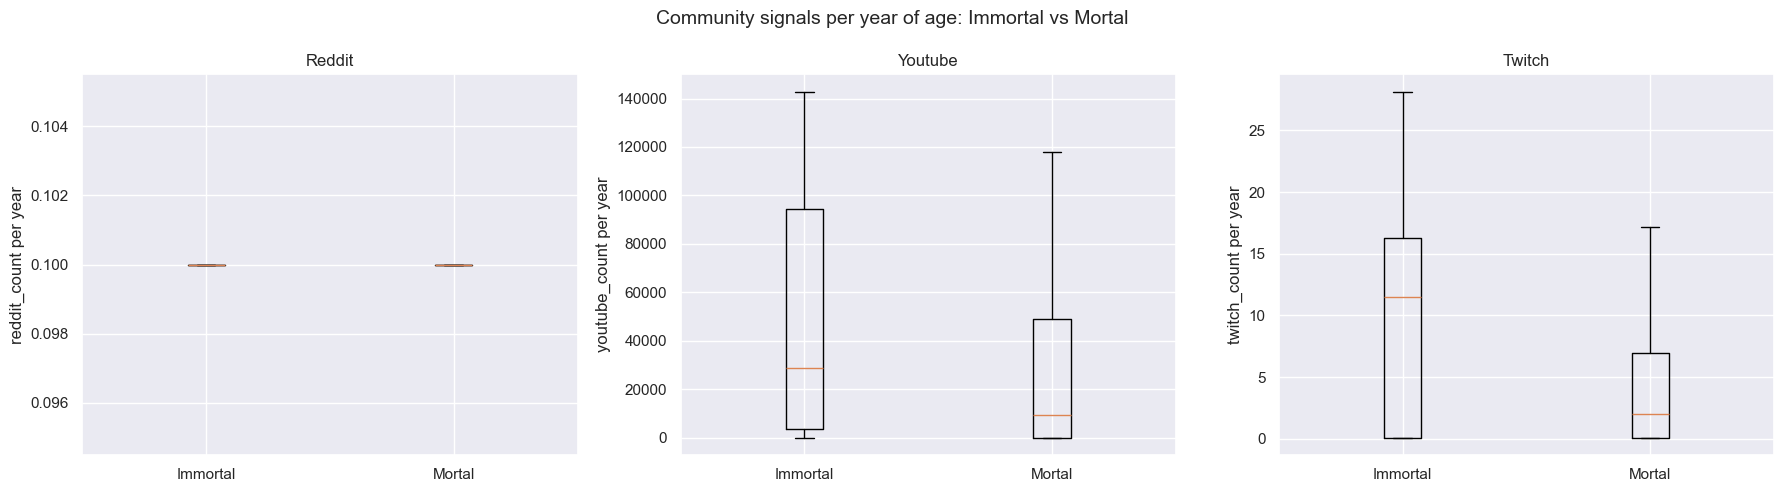

In [13]:
# Normalize community signals by age (years since release)
df_valid['age_years'] = 2025 - df_valid['release_year']
df_valid['age_years'] = df_valid['age_years'].clip(lower=1)  # avoid div by 0

for col in community_cols:
    df_valid[f'{col}_per_year'] = df_valid[col].fillna(0) / df_valid['age_years']

# Compare immortal vs mortal community signals
if len(immortal_games) > 0 and len(mortal_games) > 0:
    # Recompute with updated df_valid
    immortal_games = df_valid[immortal_mask]
    mortal_games = df_valid[mortal_mask]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, col in enumerate(community_cols):
        col_py = f'{col}_per_year'
        data = pd.DataFrame({
            'Immortal': immortal_games[col_py].describe(),
            'Mortal': mortal_games[col_py].describe()
        })
        
        # Log-scale boxplot comparison
        bp_data = [
            immortal_games[col_py].dropna().clip(lower=0.1),
            mortal_games[col_py].dropna().clip(lower=0.1)
        ]
        axes[i].boxplot(bp_data, labels=['Immortal', 'Mortal'], showfliers=False)
        axes[i].set_ylabel(f'{col} per year')
        axes[i].set_title(col.replace('_count', '').title())
    
    plt.suptitle('Community signals per year of age: Immortal vs Mortal', fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Other Variables — Metacritic, Playtime, Additions, Platforms

In [14]:
# Metacritic coverage
print('=== Metacritic ===')
print(f'Non-null: {df_valid["metacritic"].notna().sum()} ({df_valid["metacritic"].notna().mean()*100:.1f}%)')
print(df_valid['metacritic'].describe())

print('\n=== Playtime ===')
print(f'Non-null: {df_valid["playtime"].notna().sum()} ({df_valid["playtime"].notna().mean()*100:.1f}%)')
print(f'Non-zero: {(df_valid["playtime"].fillna(0) > 0).sum()}')
print(df_valid['playtime'].describe())

print('\n=== Additions Count ===')
print(f'Non-null: {df_valid["additions_count"].notna().sum()} ({df_valid["additions_count"].notna().mean()*100:.1f}%)')
print(df_valid['additions_count'].describe())

print('\n=== Game Series Count ===')
print(f'Non-null: {df_valid["game_series_count"].notna().sum()} ({df_valid["game_series_count"].notna().mean()*100:.1f}%)')
print(df_valid['game_series_count'].describe())

=== Metacritic ===
Non-null: 3987 (56.5%)
count    3987.000000
mean       76.058691
std        10.266595
min        23.000000
25%        71.000000
50%        77.000000
75%        83.000000
max        99.000000
Name: metacritic, dtype: float64

=== Playtime ===
Non-null: 5250 (74.4%)
Non-zero: 5250
count    5250.000000
mean        6.462857
std        19.536061
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       900.000000
Name: playtime, dtype: float64

=== Additions Count ===
Non-null: 1075 (15.2%)
count    1075.000000
mean        2.267907
std         2.513436
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        27.000000
Name: additions_count, dtype: float64

=== Game Series Count ===
Non-null: 3371 (47.8%)
count    3371.000000
mean       10.602788
std        11.306587
min         1.000000
25%         2.000000
50%         7.000000
75%        16.000000
max        77.000000
Name: game_series_count, dtype

In [15]:
# Platform count
def count_platforms(val):
    if pd.isna(val) or val == '':
        return 0
    return len([p.strip() for p in str(val).split('|') if p.strip()])

df_valid['n_platforms'] = df_valid['platforms'].apply(count_platforms)

print('=== Platform Count ===')
print(df_valid['n_platforms'].describe())

# Immortal vs mortal
if len(immortal_games) > 0:
    print(f'\nImmortal avg platforms: {df_valid.loc[immortal_mask, "n_platforms"].mean():.1f}')
    print(f'Mortal avg platforms: {df_valid.loc[mortal_mask, "n_platforms"].mean():.1f}')

=== Platform Count ===
count    7052.000000
mean        3.400737
std         2.182417
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        22.000000
Name: n_platforms, dtype: float64

Immortal avg platforms: 3.5
Mortal avg platforms: 3.3


## 7. Genre Parsing

In [16]:
# Parse genres
print('=== Raw genre samples ===')
for g in df_valid['genres'].dropna().head(5):
    print(repr(g))

df_valid['genre_list'] = df_valid['genres'].apply(parse_tags)  # reuse tag parser

genre_counter = Counter()
for gl in df_valid['genre_list']:
    genre_counter.update(gl)

print(f'\nUnique genres: {len(genre_counter)}')
print('\nAll genres:')
for g, c in genre_counter.most_common():
    print(f'  {g}: {c}')

=== Raw genre samples ===
'Action'
'Action|Shooter'
'Action|Puzzle'
'Sports|Racing|Indie'
'Adventure'

Unique genres: 19

All genres:
  Action: 3850
  Adventure: 2521
  Indie: 2010
  RPG: 1480
  Strategy: 1096
  Shooter: 901
  Simulation: 778
  Casual: 742
  Arcade: 663
  Platformer: 505
  Puzzle: 502
  Racing: 361
  Sports: 355
  Fighting: 273
  Massively Multiplayer: 200
  Family: 132
  Board Games: 46
  Card: 46
  Educational: 31


## 8. Mortality Index — Prototype Composite Score

Combine multiple signals into a single "immortality" predictor.
This is exploratory — the exact weighting will need tuning.

In [17]:
from sklearn.preprocessing import MinMaxScaler

idx_df = df_valid.dropna(subset=['release_year']).copy()
idx_df = idx_df[idx_df['release_year'] >= 2000]

# Dropped n_platforms (no signal) and youtube (capped at 1M)
features = {
    'alive_ratio': 1.0,
    'playing_rate': 0.5,
    'beaten_rate': -0.3,
    'playtime': 0.3,
}

for col in ['reddit_count_per_year', 'twitch_count_per_year']:
    if col in idx_df.columns and idx_df[col].notna().mean() > 0.1:
        features[col] = 0.2

print(f'Features in mortality index: {list(features.keys())}')

scaler = MinMaxScaler()
feature_cols = list(features.keys())
idx_df[feature_cols] = idx_df[feature_cols].fillna(0)

for col in feature_cols:
    p99 = idx_df[col].quantile(0.99)
    if p99 > 0:
        idx_df[col] = idx_df[col].clip(upper=p99)

idx_df[feature_cols] = scaler.fit_transform(idx_df[feature_cols])

idx_df['mortality_index'] = sum(
    idx_df[col] * weight for col, weight in features.items()
)

idx_df['mortality_index'] = (
    (idx_df['mortality_index'] - idx_df['mortality_index'].min()) /
    (idx_df['mortality_index'].max() - idx_df['mortality_index'].min()) * 100
)

print(f'\n=== Top 30 Most Immortal Games ===')
top_cols = ['name', 'release_year', 'mortality_index', 'alive_ratio', 'rating', 'genres', 'status_playing', 'engagement_total']
top_cols = [c for c in top_cols if c in idx_df.columns]
print(idx_df.nlargest(30, 'mortality_index')[top_cols].to_string())

print(f'\n=== Highly Rated but Mortal (rating >= 4.0, index < 20) ===')
beloved_dying = idx_df[(idx_df['rating'] >= 4.0) & (idx_df['mortality_index'] < 20)]
print(f'Count: {len(beloved_dying)}')
dying_cols = ['name', 'release_year', 'mortality_index', 'alive_ratio', 'rating', 'genres']
dying_cols = [c for c in dying_cols if c in idx_df.columns]
print(beloved_dying.nlargest(20, 'rating')[dying_cols].to_string())


Features in mortality index: ['alive_ratio', 'playing_rate', 'beaten_rate', 'playtime', 'reddit_count_per_year', 'twitch_count_per_year']

=== Top 30 Most Immortal Games ===
                                         name  release_year  mortality_index  alive_ratio  rating                                     genres  status_playing  engagement_total
8516                             Star Citizen        2025.0       100.000000     1.000000    3.56        Action|Shooter|Adventure|Simulation            17.0              35.0
2303                        League of Legends        2009.0        98.681196     1.000000    3.66                        Action|RPG|Strategy           332.0             881.0
6441                                     osu!        2007.0        96.502074     0.984325    4.28                               Arcade|Indie            96.0             287.0
502                          Baldurs Gate III        2023.0        95.660438     0.975270    4.44                     Adventur

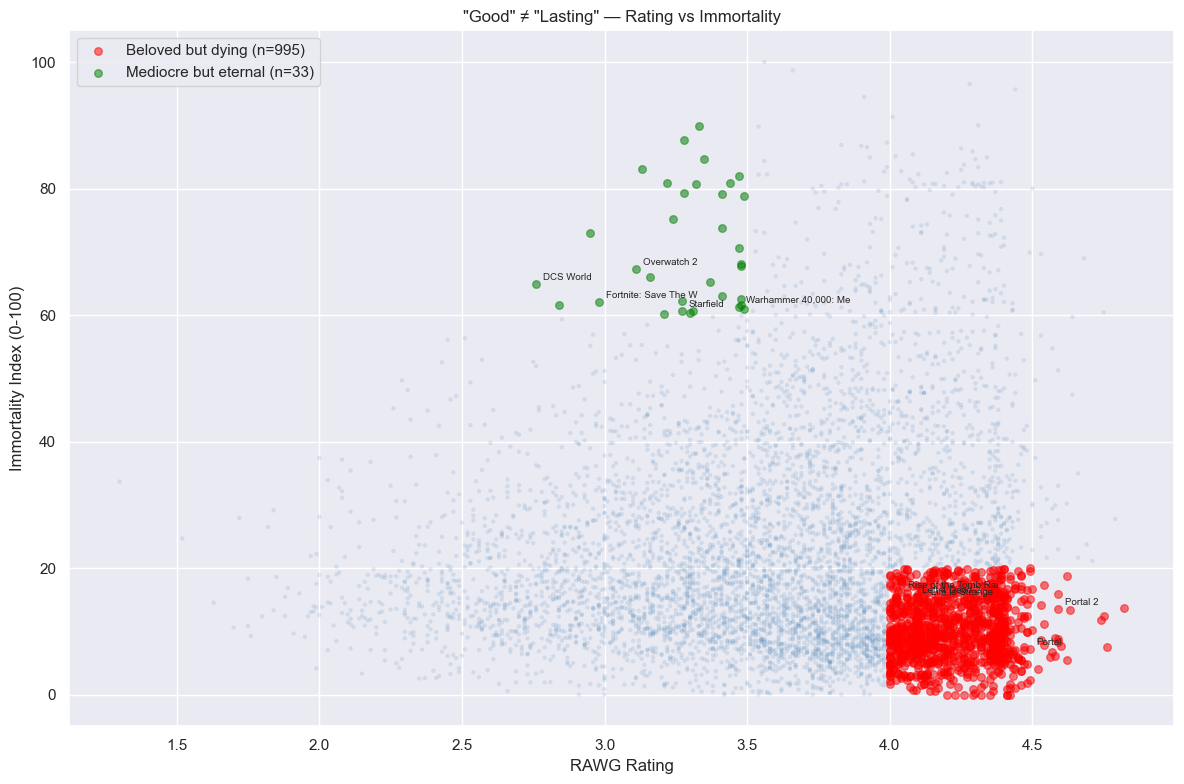

In [18]:
# === Rating vs Immortality — the core tension ===
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(idx_df['rating'], idx_df['mortality_index'],
                     alpha=0.15, s=10, c='steelblue', edgecolors='none')

# Highlight the interesting quadrants
# High rated + low immortality = "beloved but dying"
# Low rated + high immortality = "mediocre but eternal"
beloved_dying = idx_df[(idx_df['rating'] >= 4.0) & (idx_df['mortality_index'] < 20)]
mediocre_eternal = idx_df[(idx_df['rating'] < 3.5) & (idx_df['mortality_index'] > 60)]

ax.scatter(beloved_dying['rating'], beloved_dying['mortality_index'],
           s=30, c='red', alpha=0.5, label=f'Beloved but dying (n={len(beloved_dying)})')
ax.scatter(mediocre_eternal['rating'], mediocre_eternal['mortality_index'],
           s=30, c='green', alpha=0.5, label=f'Mediocre but eternal (n={len(mediocre_eternal)})')

# Annotate a few
for df_subset, n in [(beloved_dying, 5), (mediocre_eternal, 5)]:
    for _, row in df_subset.head(n).iterrows():
        ax.annotate(row['name'][:20], (row['rating'], row['mortality_index']),
                    fontsize=7, ha='left', xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('RAWG Rating')
ax.set_ylabel('Immortality Index (0-100)')
ax.set_title('"Good" ≠ "Lasting" — Rating vs Immortality')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Feasibility Summary

Run this cell after all the above to get a go/no-go on each story beat.

In [19]:
IMMORTAL_YEAR_CUTOFF = 2018
IMMORTAL_ALIVE_THRESH = 0.10
MORTAL_ALIVE_THRESH = 0.03

immortal_mask_final = (df_valid['release_year'] <= IMMORTAL_YEAR_CUTOFF) & (df_valid['alive_ratio'] > IMMORTAL_ALIVE_THRESH)
mortal_mask_final = (df_valid['release_year'] <= IMMORTAL_YEAR_CUTOFF) & (df_valid['alive_ratio'] <= MORTAL_ALIVE_THRESH)

print('=' * 60)
print('FEASIBILITY SUMMARY (adjusted thresholds)')
print('=' * 60)

checks = {
    f'Games with engagement >= {MIN_ENGAGEMENT}': len(df_valid),
    'Games with valid release year': df_valid['release_year'].notna().sum(),
    'Games with alive_ratio computable': df_valid['alive_ratio'].notna().sum(),
    'Unique tags found': len(all_tags),
    'Games with tags': (df_valid['n_tags'] > 0).sum(),
    'Games with metacritic': df_valid['metacritic'].notna().sum(),
    'Games with reddit_count > 0': (df_valid['reddit_count'].fillna(0) > 0).sum(),
    'Games with twitch_count > 0': (df_valid['twitch_count'].fillna(0) > 0).sum(),
    'Games with playtime > 0': (df_valid['playtime'].fillna(0) > 0).sum(),
    f'Immortals (pre-{IMMORTAL_YEAR_CUTOFF}, alive>{IMMORTAL_ALIVE_THRESH})': immortal_mask_final.sum(),
    f'Mortals (pre-{IMMORTAL_YEAR_CUTOFF}, alive<={MORTAL_ALIVE_THRESH})': mortal_mask_final.sum(),
}

for check, val in checks.items():
    status = '✅' if val > 100 else '⚠️' if val > 30 else '❌'
    print(f'{status} {check}: {val:,}')

print()
print('KEY DECISIONS:')
print('  ✂️  CUT: Platform spread (3.7 vs 3.6 — no signal)')
print('  ✂️  CUT: YouTube count (capped at 1M — no dynamic range)')
print('  ✅ KEEP: Twitch (best community signal)')
print('  ✅ KEEP: Reddit (clean but sparse — supplementary)')
print('  🔧 ADJUSTED: Immortal threshold 0.15→0.10, year cutoff 2016→2018')
print('  🔧 ADJUSTED: Mortal threshold 0.05→0.03 (stricter = cleaner contrast)')


FEASIBILITY SUMMARY (adjusted thresholds)
✅ Games with engagement >= 30: 7,052
✅ Games with valid release year: 7,033
✅ Games with alive_ratio computable: 7,052
✅ Unique tags found: 1,839
✅ Games with tags: 6,537
✅ Games with metacritic: 3,987
✅ Games with reddit_count > 0: 1,124
✅ Games with twitch_count > 0: 4,638
✅ Games with playtime > 0: 5,250
✅ Immortals (pre-2018, alive>0.1): 690
✅ Mortals (pre-2018, alive<=0.03): 2,739

KEY DECISIONS:
  ✂️  CUT: Platform spread (3.7 vs 3.6 — no signal)
  ✂️  CUT: YouTube count (capped at 1M — no dynamic range)
  ✅ KEEP: Twitch (best community signal)
  ✅ KEEP: Reddit (clean but sparse — supplementary)
  🔧 ADJUSTED: Immortal threshold 0.15→0.10, year cutoff 2016→2018
  🔧 ADJUSTED: Mortal threshold 0.05→0.03 (stricter = cleaner contrast)


## 10. Export Preview Data for D3 Prototyping

If everything looks good, export a trimmed JSON for early D3 experiments.

In [20]:
import os

# Export top ~10k games (by engagement) with all needed fields
export_df = df_valid.nlargest(10000, 'engagement_total').copy()

export_cols = {
    'name': 'name',
    'release_year': 'year',
    'alive_ratio': 'alive',
    'beaten_rate': 'beaten',
    'playing_rate': 'playing',
    'dropped_rate': 'dropped',
    'engagement_total': 'engagement',
    'rating': 'rating',
    'metacritic': 'metacritic',
    'playtime': 'playtime',
    'n_platforms': 'platforms',
    'genres': 'genres',
    'tags': 'tags',
    'reddit_count': 'reddit',
    'youtube_count': 'youtube',
    'twitch_count': 'twitch',
    'additions_count': 'additions',
    'game_series_count': 'series',
    'status_playing': 'raw_playing',
    'status_beaten': 'raw_beaten',
    'status_dropped': 'raw_dropped',
    'status_owned': 'raw_owned',
}

out = export_df[list(export_cols.keys())].rename(columns=export_cols)
out = out.round(4)

out.to_json('games_d3_preview.json', orient='records', indent=2)
print(f'Exported {len(out)} games to games_d3_preview.json')
print(f'File size: {os.path.getsize("games_d3_preview.json") / 1024 / 1024:.1f} MB')

Exported 7052 games to games_d3_preview.json
File size: 4.2 MB
